<a href="https://colab.research.google.com/github/antohachekhov/AlloySegmentation-DeepLearning/blob/main/NeuralNetworkTransitionLayer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Подключаемые библиотеки

In [ ]:
import glob
import keras
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Импорт и аугментация датасета

In [65]:
DATASET_FOLDER = './dataset'

#Зададим размер batch и размер изображения
TRAIN_DATASET_COUNT = 40
VAL_DATASET_COUNT = 10

BATCH_SIZE = 64
BUFFER_SIZE = 1000
IMG_SHAPE  = (256, 256)
OUTPUT_SIZE = (665, 1024)

REPEATS = 5
TRAIN_LENGTH = TRAIN_DATASET_COUNT * REPEATS
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

CLASSES = 3
SPECIFIC_CLASS = 1 # номер класса переходного слоя

# Класс 1 (0) - металл шероховатый (one-hot [1, 0, 0])
# Класс 2 (1) - переходный слой (one-hot [0, 1, 0])
# Класс 3 (2) - металл менее шероховатый (one-hot [0, 0, 1])

CLASS_COLORS = {
    1: [113, 222, 111],
    2: [217, 60, 134],
    3: [217, 208, 71]
}

PATCHES = [mpatches.Patch(color=list(map(lambda x: x / 255, CLASS_COLORS[1])), label='Metal1'),
           mpatches.Patch(color=list(map(lambda x: x / 255, CLASS_COLORS[2])), label='Transition Layer'),
           mpatches.Patch(color=list(map(lambda x: x / 255, CLASS_COLORS[3])), label='Metal2')]

In [ ]:
# Функция для загрузки изображения
def load_data(image, mask):
    #Загружаем и препроцессим изображения
    image = tf.io.read_file(image)
    image = tf.io.decode_png(image)
    image = tf.image.resize(image, OUTPUT_SIZE)
    image = tf.image.resize(image, IMG_SHAPE)
    image = tf.image.rgb_to_grayscale(image) # РАСКОМЕНТИРОВАНО ДЛЯ CCE Loss
    image = tf.image.grayscale_to_rgb(image) # РАСКОМЕНТИРОВАНО ДЛЯ CFCE Loss
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = image / 255.0

    #Загружаем и препроцессим маски изображений
    mask = tf.io.read_file(mask)
    mask = tf.io.decode_png(mask)
    # mask = tf.image.grayscale_to_rgb(mask) #Если маски сохранены в GRAY
    # mask = tf.image.rgb_to_grayscale(mask)
    mask = tf.image.resize(mask, OUTPUT_SIZE)
    mask = tf.image.resize(mask, IMG_SHAPE, method='nearest')
    mask = tf.one_hot(tf.cast(tf.squeeze(mask-1, axis=-1), tf.uint8), depth=CLASSES)
    # mask = tf.keras.utils.to_categorical(mask, num_classes=3)
    # mask = tf.image.convert_image_dtype(mask, tf.float32)
    # mask -= 1
    return image, mask


# Функция загрузки имени файлов изображений и масок
def load_filenames(path):
    images_filenames = sorted(glob.glob(f'{path}/imgPNG/*.png'))
    masks_filenames = sorted(glob.glob(f'{path}/mask/*.png'))
    if len(images_filenames) == len(masks_filenames):
        if len(images_filenames):
          print(f'Found {len(images_filenames)} images and masks')
        else:
          raise Exception('There is no images and masks')
    else:
        raise Exception('The number of images and masks is different')
    return images_filenames, masks_filenames


# Функция создания датасета
def createDataset(imagesPaths, masksPaths):
    dataset = tf.data.Dataset.zip((tf.data.Dataset.from_tensor_slices(imagesPaths),
                                tf.data.Dataset.from_tensor_slices(masksPaths)))

    dataset = dataset.map(load_data) # , num_parallel_calls=tf.data.AUTOTUNE)
    return dataset

**Аугментация**


---


*RandomRotation*

Входной параметр представляет нижнюю и верхнюю границы вращения по часовой стрелке и против часовой стрелки.

Например, значение параметра $(-0.2, 0.3)$ приводит к вращению на случайную величину в диапазоне $[-20\% \cdot 2π, 30\% \cdot 2\pi]$. Параметр $0.2$ приводит к вращению выходного сигнала на случайную величину в диапазоне $[-20\% \cdot 2π, 20\% \cdot 2\pi]$.

Если вращение должно быть не больше $10^{\circ}$, значит параметр должен быть равен $\frac{10}{2\cdot180}=\frac{1}{2\cdot 18}=\frac{1}{36}\approx0.03$.


In [ ]:
# Аугментация - поворот изображения на не более 10 градусов
class Augment(tf.keras.layers.Layer):
    def __init__(self, seed=12):
        super().__init__()
        # both use the same seed, so they'll make the same random changes.
        self.augment_inputs = tf.keras.layers.RandomRotation(0.03, seed=seed, fill_mode='reflect', interpolation="nearest")
        self.augment_labels = tf.keras.layers.RandomRotation(0.03, seed=seed, fill_mode='reflect', interpolation="nearest")

    def call(self, inputs, labels):
        inputs = self.augment_inputs(inputs)
        labels = self.augment_labels(labels)
        return inputs, labels

In [66]:
imagesTrain, masksTrain = load_filenames(f'{DATASET_FOLDER}/train')
datasetTrain = createDataset(imagesTrain, masksTrain)

train_batches = (
    datasetTrain
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat(REPEATS)
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE))

print(f'Train dataset contains {len(datasetTrain)} objects')
print(f'Train batched dataset contains {len(train_batches)} batches')

Found 40 images and masks
Train dataset contains 40 objects
Train batched dataset contains 5 batches


In [67]:
imagesVal, masksVal = load_filenames(f'{DATASET_FOLDER}/val')
datasetVal = createDataset(imagesVal, masksVal)
val_batches = datasetVal.repeat(REPEATS).map(Augment()).batch(BATCH_SIZE)
print(f'Train dataset contains {len(datasetVal)} objects')
print(f'Train batched dataset contains {len(val_batches)} batches')

Found 10 images and masks
Train dataset contains 10 objects
Train batched dataset contains 1 batches


## Визуализация обучающих и валидационных данных после batch

In [ ]:
def display(display_list):
  plt.figure(figsize=(15, 15))

  title = ['Input Image', 'True Mask', 'Predicted Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

def getColorMask(mask):
    mask_rgb = np.zeros(mask.shape, dtype=np.uint8)
    for i in range(CLASSES):
        mask_rgb[mask[:, :, i]==1]=np.array(CLASS_COLORS[i+1])
    return mask_rgb

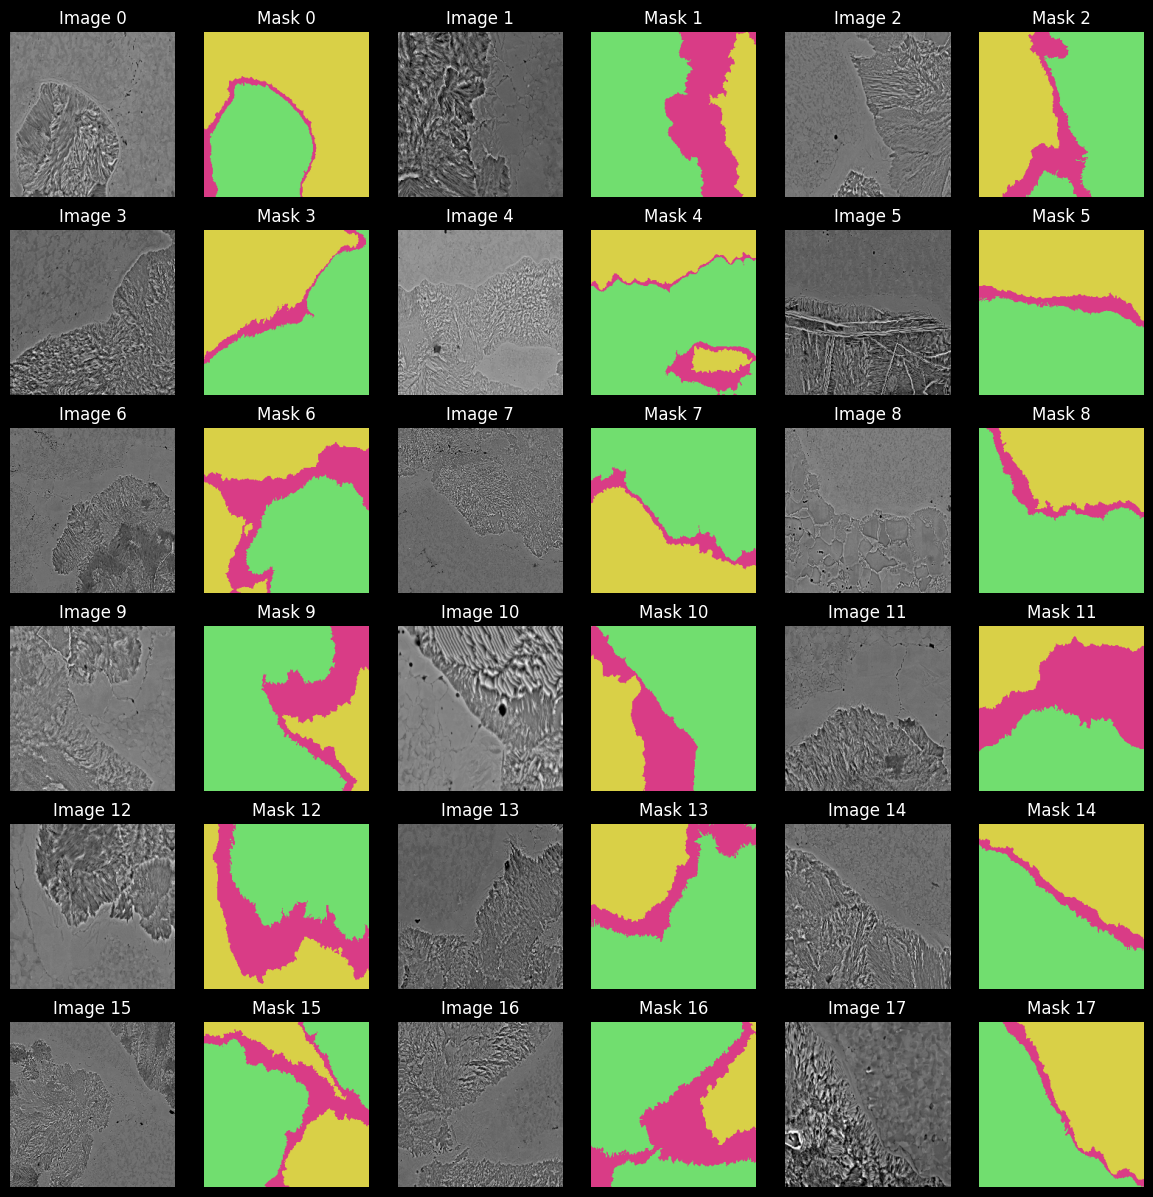

In [ ]:
(images, masks) = list(train_batches.take(1))[0]
rowCount, colCount = 6, 3
fig, axis = plt.subplots(rowCount, colCount * 2, figsize=(15, 15))

for i in range(rowCount):
    for j in range(colCount):
        axis[i, j * 2].imshow(tf.keras.utils.array_to_img(images[i * colCount + j]))
        axis[i, j * 2].set_axis_off()
        axis[i, j * 2].set_title(f'Image {i * colCount + j}')

        axis[i, j * 2 + 1].imshow(getColorMask(masks[i * colCount + j]))
        axis[i, j * 2 + 1].set_title(f'Mask {i * colCount + j}')
        axis[i, j * 2 + 1].set_axis_off()

plt.subplots_adjust(wspace=0)
plt.show()

# Функция потерь

## Categorical crossentropy

$CCE=-\displaystyle\sum_{i=1}^{n}{y_{i}\cdot\ln{\hat{y}_i}}$

Кросс-энтропия  — это мера разницы между прогнозируемым распределением вероятностей и истинным распределением вероятностей.

В этой формуле логарифм гарантирует, что за неправильные прогнозы будет серьёзное наказание.

In [ ]:
loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0, from_logits=False)

## Categorical Focal Crossentropy

Применяет коэффициент фокуса, чтобы уменьшить значимость простых примеров и уделить больше внимания сложным примерам

$FL=α⋅(1-p_{t})^{γ}⋅CCE(y,\hat{y})$,

где $p_t=\text{output if } y_t=1\text{ else }1-\text{output}$,

$γ$ — параметр фокусировки. Когда $γ=0$, эффект фокусировки на кросс-энтропии отсутствует. $γ$ плавно снижает важность простых примеров.

$\alpha$ — весовой коэффициент для классов. Если $\alpha=1$, то модель не сможет правильно обрабатывать дисбаланс классов, так как все классы будут иметь одинаковый вес.


In [68]:
loss = tf.keras.losses.CategoricalFocalCrossentropy(gamma=0.5,
                                                    from_logits=False)

## Dice

$DL=1-\frac{2\sum_{i}^{N}{\hat{y}_{i}y_{i}}+ϵ}{\sum_{i}^{N}{\hat{y}_{i}^{2}+\sum_{i}^{N}{y_{i}^{2}}}+ϵ}$, где $ϵ$ это сглаживающий член, позволяющий избежать деления на ноль и сохранить стабильность функции потерь.

Она количественно оценивает сходство между предсказанной сегментацией и истиной путём вычисления коэффициента Dice, который определяется как пересечение предсказанных и истинных положительных значений, делённое на общее количество положительных значений в обоих наборах.

In [ ]:
loss = tf.keras.losses.Dice()

In [ ]:
#|Dice Coefficient for binary Segmentation task
@keras.saving.register_keras_serializable()
def dice_calculator(mask_true, mask_pred):

    num_sum = 2.0 * tf.keras.backend.sum(mask_true * mask_pred) + tf.keras.backend.epsilon()
    den_sum = tf.keras.backend.sum(tf.keras.backend.square(mask_true)) + tf.keras.backend.sum(tf.keras.backend.square(mask_pred))+ tf.keras.backend.epsilon()
    dise=(num_sum/den_sum)

    return dise
#|Average Dice Loss for multiclass-Segmenatiom task
@keras.saving.register_keras_serializable()
def Avg_Dice_loss(y_true, y_predicted, num_classes=3):
    print(y_predicted.numpy())
    clas_dice_list=[]
    for i in range(0,num_classes):
        mask_true = tf.keras.backend.flatten(y_true[:, :, :, i])#
        mask_pred = tf.keras.backend.flatten(y_predicted[:, :, :, i])#
        class_dice=dice_calculator(mask_true,mask_pred)
        clas_dice_list.append(class_dice)
    avg_dice=tf.math.reduce_mean(clas_dice_list,axis=0)
    dice_loss=1-avg_dice
    return dice_loss

#|Average Dice matricx for multiclass-Segmenatiom task
@keras.saving.register_keras_serializable()
def Avg_Dice_matrix(y_true, y_predicted,num_classes=31):
    clas_dice_list=[]
    for i in range(0,num_classes):
        mask_true = tf.keras.backend.flatten(y_true[:, :, :, i])#
        mask_pred = tf.keras.backend.flatten(y_predicted[:, :, :, i])#
        class_dice=dice_calculator(mask_true,mask_pred)
        clas_dice_list.append(class_dice)
    avg_dice=tf.math.reduce_mean(clas_dice_list,axis=0)
    dice_score=tf.print(clas_dice_list[2:9],summarize=10)

    return avg_dice

In [ ]:
loss = Avg_Dice_loss

# Метрики

In [69]:
METRICS = []

## Матрица ошибок для мультиклассовой классификации

$$
\begin{array}{llll}
\text{actual\\predict}
       & \text{class1}   & \text{class2}   & \text{class3}   \\
\text{class1} & \text{cell}_{1,1} & \text{cell}_{1,2} & \text{cell}_{1,3} \\
\text{class2} & \text{cell}_{2,1} & \text{cell}_{2,2} & \text{cell}_{2,3} \\
\text{class3} & \text{cell}_{3,1} & \text{cell}_{3,2} & \text{cell}_{3,3}
\end{array}
$$

$TP_{\text{class1}}=\text{cell}_{1,1}$

$FN_{\text{class1}}=\text{cell}_{1,2}+\text{cell}_{1,3}$

$FP_{\text{class1}}=\text{cell}_{2,1}+\text{cell}_{3,1}$

$TN_{\text{class1}}=\text{cell}_{2,2}+\text{cell}_{2,3}+\text{cell}_{3,2}+\text{cell}_{3,3}$

$$
\text{TP}_{\text{class }i}=\text{cell}_{i, i} \\
\text{FN}_{\text{class }i}=\sum_{j\ne i}\text{cell}_{i, j} \\
\text{FP}_{\text{class }i}=\sum_{j\ne i}\text{cell}_{j, i} \\
\text{TN}_{\text{class }i}=\sum_{j\ne i,k\ne i}\text{cell}_{j, k}
$$

## Categorical Accuracy

In [70]:
METRICS.append(tf.keras.metrics.CategoricalAccuracy())

## IoU

$$\text{IoU} = \frac{TP}{TP + FP + FN}$$

`target_class_ids` - Кортеж или список идентификаторов целевого класса, для которого возвращается метрика. Чтобы вычислить IoU для определенного класса, должен быть предоставлен список (или кортеж) с одним значением идентификатора.

In [ ]:
METRICS.append(tf.keras.metrics.OneHotIoU(num_classes=CLASSES, target_class_ids=[0]))

In [71]:
METRICS.append(tf.keras.metrics.OneHotIoU(num_classes=CLASSES, target_class_ids=[1]))

In [ ]:
METRICS.append(tf.keras.metrics.OneHotIoU(num_classes=CLASSES, target_class_ids=[2]))

## Mean IoU

In [72]:
METRICS.append(tf.keras.metrics.OneHotMeanIoU(num_classes=3))

# Функции активации

## Softmax

$$
\hat{y}_i=\text{softmax}(z_i)=\frac{e^{z_i}}{∑_{j=1}^K{e^{z_j}}}
$$

In [73]:
activation = 'softmax'

# Сборка модели

In [ ]:
!pip install git+https://github.com/tensorflow/examples.git

  Cloning https://github.com/tensorflow/examples.git to C:\Users\bortn\AppData\Local\Temp\pip-req-build-_zmdxrif
  Resolved https://github.com/tensorflow/examples.git to commit 1719c46f437d01ef52e4817591e4e00365ab7682
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/examples.git 'C:\Users\bortn\AppData\Local\Temp\pip-req-build-_zmdxrif'


In [74]:
from tensorflow_examples.models.pix2pix import pix2pix

base_model = tf.keras.applications.MobileNetV2(input_shape=[*IMG_SHAPE, 3], include_top=False)

# Use the activations of these layers
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

# Create the feature extraction model
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)

down_stack.trainable = False

up_stack = [
    pix2pix.upsample(512, 3),  # 4x4 -> 8x8
    pix2pix.upsample(256, 3),  # 8x8 -> 16x16
    pix2pix.upsample(128, 3),  # 16x16 -> 32x32
    pix2pix.upsample(64, 3),   # 32x32 -> 64x64
]

def unet_model(output_channels:int):
  inputs = tf.keras.layers.Input(shape=[*IMG_SHAPE, 3])

  # Downsampling through the model
  skips = down_stack(inputs)
  x = skips[-1]
  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    concat = tf.keras.layers.Concatenate()
    x = concat([x, skip])

  # This is the last layer of the model
  last = tf.keras.layers.Conv2DTranspose(
      filters=output_channels, kernel_size=3, strides=2,
      padding='same', activation=activation)  #64x64 -> 128x128

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

/tmp/ipykernel_16064/1463828980.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=[*IMG_SHAPE, 3], include_top=False)


In [75]:
model = unet_model(output_channels=CLASSES)
model.compile(optimizer='adam',
              loss=loss,
              metrics=METRICS)

# Визуализация результатов

In [76]:
def display(display_list):
    fig, axis = plt.subplots(1, 3, figsize=(15, 15))

    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        axis[i].set_title(title[i])
        #plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
        axis[i].imshow(display_list[i])
        if i != 0:
            axis[i].legend(bbox_to_anchor=(0., -0.09, 1., .102), loc='lower left',
                         ncols=3, mode="expand", borderaxespad=0., handles=PATCHES)
        axis[i].axis('off')
    plt.show()

def create_mask(pred_mask):
    pred_mask = tf.math.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    pred_mask = tf.one_hot(tf.cast(tf.squeeze(pred_mask, axis=-1), tf.uint8), depth=CLASSES)
    return pred_mask[0]

# def getColorMask(one_hot_mask):
#     mask = tf.cast(one_hot_mask, tf.uint8)
#     mask = one_hot_mask.numpy()
#     # maskOut = one_hot_mask.numpy()
#     # print(mask)
#     for i in range(CLASSES):
#         # print(mask[mask[:,:,i]==1])
#         mask[mask[:,:,i]==1]=np.array(CLASS_COLORS[i+1])
#         # maskOut[np.argmax(mask, axis=2)==i]=np.array(CLASS_COLORS[i+1])
#     mask = tf.cast(mask, tf.uint8)
#     return mask

def show_predictions(dataset=None, num=1):
    if dataset:
        # for image, mask in dataset.take(num):
        for image, mask in train_batches.take(num):
                pred_mask = model.predict(image)
                display([image[0], getColorMask(mask[0]), getColorMask(create_mask(pred_mask))])
    else:
        display([sample_image, getColorMask(sample_mask),
                 getColorMask(create_mask(model.predict(sample_image[tf.newaxis, ...])))])

Тестирование до обучения модели

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


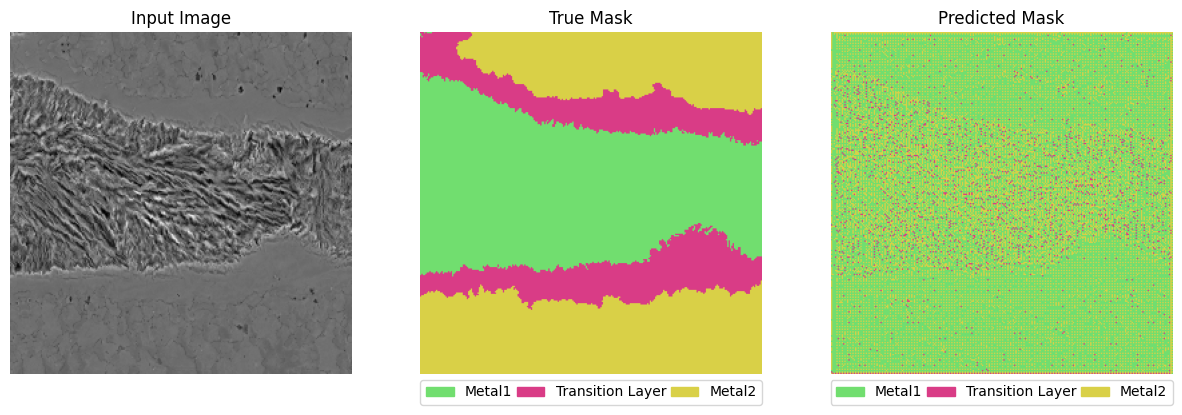

In [77]:
[images, masks] = list(train_batches.take(1))[0]
sample_image, sample_mask = images[0], masks[0]
show_predictions()

# Обучение модели

In [78]:
from IPython.display import clear_output

class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_predictions()
    print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

In [80]:
train = train_batches
val = val_batches

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


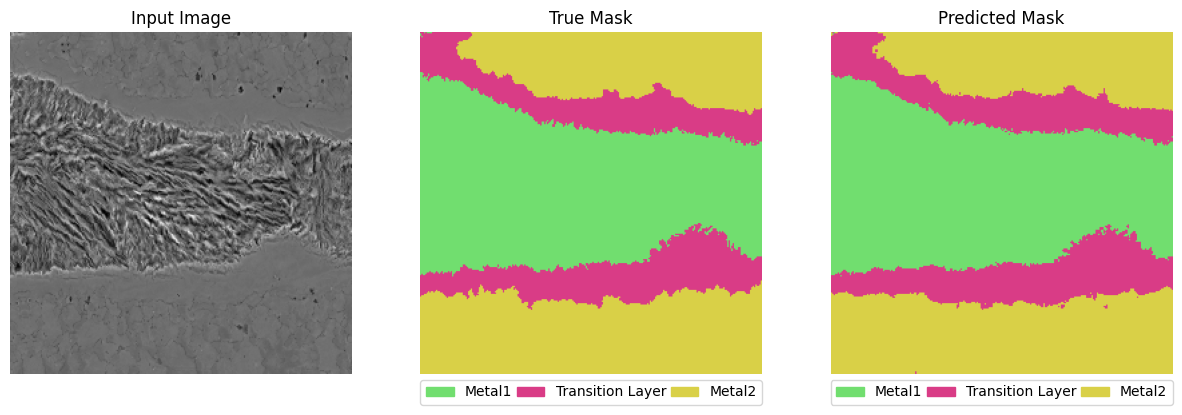


Sample Prediction after epoch 50

5/5 ━━━━━━━━━━━━━━━━━━━━ 91s 19s/step - categorical_accuracy: 0.9863 - loss: 0.0064 - one_hot_io_u_2: 0.9082 - one_hot_mean_io_u_2: 0.9578 - val_categorical_accuracy: 0.9252 - val_loss: 0.0411 - val_one_hot_io_u_2: 0.5678 - val_one_hot_mean_io_u_2: 0.7955


In [81]:
EPOCHS = 50

model_history = model.fit(train, epochs=EPOCHS,
                          # steps_per_epoch=STEPS_PER_EPOCH,
                          # validation_steps=VALIDATION_STEPS,
                          validation_data=val,
                          callbacks=[DisplayCallback()])

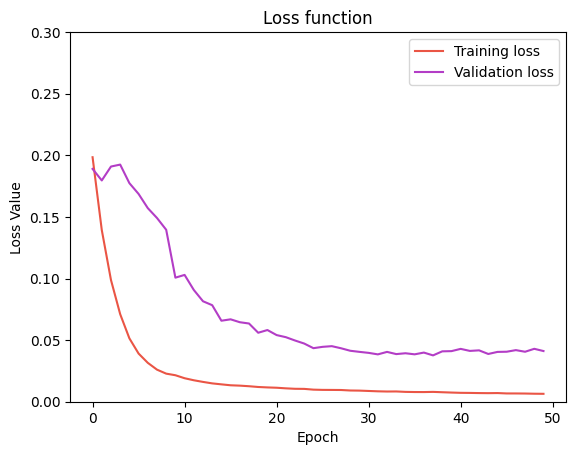

In [83]:
plotLoss(ylimMax=0.3)

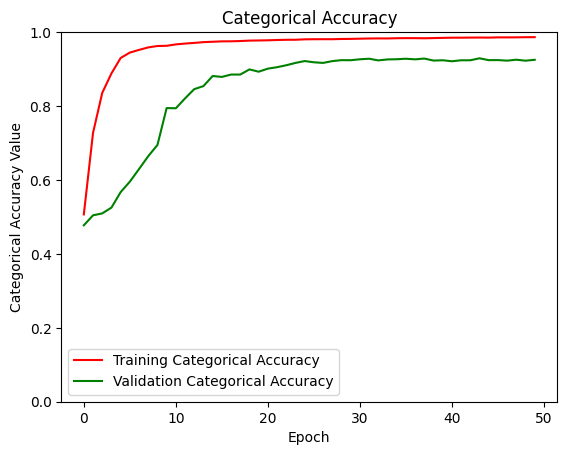

In [84]:
plotCA()

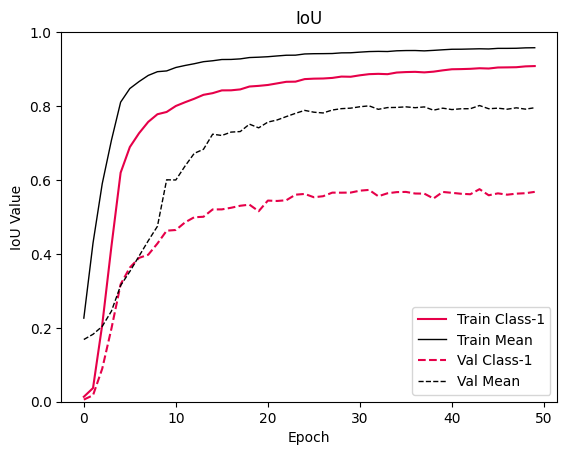

In [91]:
plotIoU(ylimMax=1)

In [90]:
def plotLoss(loss=None, val_loss=None, epoch=None, ylimMax=0.2, nameLoss=''):
  if loss is None and val_loss is None:
    loss = model_history.history['loss']
    val_loss = model_history.history['val_loss']
    epoch = model_history.epoch

  title = 'Loss function'
  if nameLoss:
    title += f' ({nameLoss})'

  plt.plot(epoch, loss, "#ea5545", label='Training loss')
  plt.plot(epoch, val_loss, "#b33dc6", label='Validation loss')
  plt.ylim([0, ylimMax])
  plt.title(title)
  plt.xlabel('Epoch')
  plt.ylabel('Loss Value')
  plt.legend()
  plt.show()


def plotCA(ca=None, valca=None, epoch=None):
  if ca is None:
    ca = model_history.history['categorical_accuracy']
    valca = model_history.history['val_categorical_accuracy']
    epoch = model_history.epoch

  plt.plot(epoch, ca, 'r', label='Training Categorical Accuracy')
  plt.plot(epoch, valca, 'g', label='Validation Categorical Accuracy')
  plt.ylim([0, 1])
  plt.title('Categorical Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Categorical Accuracy Value')
  plt.legend()
  plt.show()


def plotIoU(ylimMax=1.5, nameLoss=''):
    cls1 = model_history.history['one_hot_io_u_2']
    mean = model_history.history['one_hot_mean_io_u_2']
    valcls1 = model_history.history['val_one_hot_io_u_2']
    valMean = model_history.history['val_one_hot_mean_io_u_2']
    epoch = model_history.epoch
    title = 'Loss function'
    plt.plot(epoch, cls1, color="#e60049", label='Train Class-1')
    plt.plot(epoch, mean, 'black', linewidth=1, label='Train Mean')
    plt.plot(epoch, valcls1, color="#e60049", linestyle='--', label='Val Class-1')
    plt.plot(epoch, valMean, 'black', linewidth=1, linestyle='--', label='Val Mean')
    plt.title('IoU')
    plt.xlabel('Epoch')
    plt.ylabel('IoU Value')
    plt.ylim([0, ylimMax])
    plt.legend()

    plt.show()

# Экспорт модели

In [92]:
model.save('/content/drive/MyDrive/Университет/Аспирантура/Диссертация/Модели/NEW_50ep256io_lossCFCE0.5.keras')

# Тестирование

In [93]:
import os
from skimage.io import imread
from skimage.transform import resize

In [94]:
def loadMaskOneHot(maskPath):
    mask = tf.io.read_file(maskPath)
    mask = tf.io.decode_png(mask)
    mask = tf.image.resize(mask, OUTPUT_SIZE)
    return mask

def normalizeMask(mask):
    mask = tf.image.resize(mask, IMG_SHAPE, method='nearest')
    mask = tf.one_hot(tf.cast(tf.squeeze(mask-1, axis=-1), tf.uint8), depth=CLASSES)
    return mask

In [95]:
IoU_class2 = tf.keras.metrics.OneHotIoU(num_classes=CLASSES, target_class_ids=[1])
IoU_mean = tf.keras.metrics.OneHotMeanIoU(num_classes=CLASSES)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


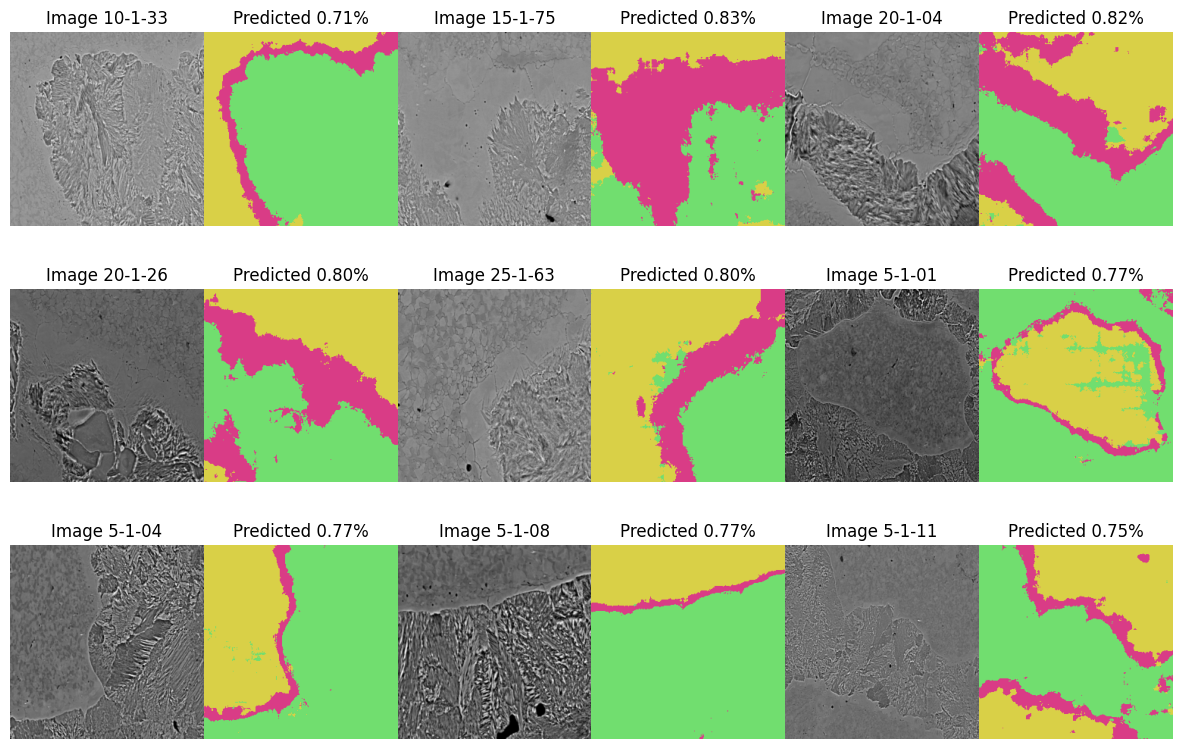

In [97]:
imagesTestPath = sorted(glob.glob(f'{DATASET_FOLDER}/test/imgPNG/*.png'))
masksTestPath = sorted(glob.glob(f'{DATASET_FOLDER}/test/mask/*.png'))
pathsDatasetForTest = list(zip(imagesTestPath, masksTestPath))

rowCount, colCount = 3, 3
fig, axis = plt.subplots(rowCount, colCount * 2, figsize=(15, 10))

datasetTest = [] # Список, хранящий тестовый датасет (название изображения,
                 # изображение, предсказанная маска, истинная маска, значение IoU-2,
                 # IoU-Mean).

for i in range(rowCount):
  for j in range(colCount):
    imagePath, maskPath = pathsDatasetForTest[i * colCount + j]
    imageTest = imread(imagePath)
    sample = resize(imageTest, IMG_SHAPE)
    predict = model.predict(sample.reshape((1,) +  IMG_SHAPE + (3,)))

    maskTrue = loadMaskOneHot(maskPath)
    maskTrueNorm = normalizeMask(maskTrue)

    maskPred = create_mask(predict)
    imageName = os.path.basename(imagePath).split('.')[0]

    iou2 = IoU_class2(maskTrueNorm, maskPred).numpy()

    datasetTest.append((imageName, sample, maskPred, maskTrue,
                        iou2,
                        IoU_mean(maskTrueNorm, maskPred).numpy()))

    axis[i, j * 2].imshow(tf.keras.utils.array_to_img(np.array(sample * 255, dtype=np.uint8)))
    axis[i, j * 2].set_axis_off()
    axis[i, j * 2].set_title(f'Image {imageName}')

    axis[i, j * 2 + 1].imshow(getColorMask(maskPred))
    axis[i, j * 2 + 1].set_title(f'Predicted {iou2:.2f}%')
    axis[i, j * 2 + 1].set_axis_off()

plt.subplots_adjust(hspace=0, wspace=0)
plt.show()

# Измерение переходного слоя

## Создание бинарных масок

In [117]:
# Создание бинарных масок, где белая область - предсказанная область переходного слоя
binaryImagesNormalize = [] # Список предсказанных бинарных масок, соответствующих объектам тестового датасета из datasetTest

for _, _, maskPred, *_ in datasetTest:
  maskPred = tf.math.argmax(maskPred, axis=-1)
  maskPred = maskPred[..., tf.newaxis]
  maskBinary = maskPred.numpy().copy()
  maskBinary[maskBinary == 1] = 255
  maskBinary = np.array(maskBinary, dtype=np.uint8)
  binaryImagesNormalize.append(maskBinary)

In [119]:
import cv2 as cv

# Приведение масок к оригинальным размерам
def binaryMaskProcessing(mask):
  _, maskThread = cv.threshold(mask, 127, 255, cv.THRESH_BINARY)
  # "открытие" изображения (удаление мелких объектов) с эллиптическим ядром 7х7
  kernel = cv.getStructuringElement(cv.MORPH_RECT, (7, 7))
  maskAfterOpen = cv.morphologyEx(maskThread, cv.MORPH_OPEN, kernel)

  # "закрытие" изображения (заполнение мелких пропусков в объектах) с эллиптическим ядром 5х5
  kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
  maskAfterClose = cv.morphologyEx(maskAfterOpen, cv.MORPH_CLOSE, kernel)

  # выделение объектов на изображении и составление статистики
  contours, hierarchy = cv.findContours(maskAfterClose.copy(), cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
  cv.drawContours(maskAfterClose, contours, -1, 100, 2, cv.LINE_AA, hierarchy, 3)
  nb_components, output, stats, centroids = cv.connectedComponentsWithStats(maskAfterClose, 4, cv.CV_32S)

  # вычисление средней площади всех объектов
  meanS = np.mean(stats[1:, -1])

  # массив для маски с областями для сегментации
  maskAfterFilter = np.zeros(output.shape, dtype=np.uint8)

  # заполнение маски
  for i in range(1, nb_components):
      # заносятся только те объекты, площадь которых больше средней площади всех объектов
      if stats[i, -1] >= meanS:
          maskAfterFilter[output == i] = 255

  return maskAfterFilter

  # # наращивание объектов
  radius = 10
  kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (radius, radius))
  return cv.dilate(maskAfterFilter, kernel)


binaryImages = [] # Список кортежей (денормализованная бинарная маска, значение IoU)
IoU_bin = tf.keras.metrics.IoU(num_classes=2, target_class_ids=[1])

for n, maskPredNorm in enumerate(binaryImagesNormalize):
  maskPredResize = cv.resize(maskPredNorm, OUTPUT_SIZE[::-1])
  maskPredAfterProcessing = binaryMaskProcessing(maskPredResize)

  maskTrue = tf.one_hot(tf.cast(tf.squeeze(datasetTest[n][3].numpy()-1, axis=-1), tf.uint8), depth=CLASSES)
  maskTrue = np.reshape(maskTrue.numpy()[:, :, 1], (*OUTPUT_SIZE, 1))
  maskPred = np.reshape(maskPredAfterProcessing/255, (*OUTPUT_SIZE, 1))
  iou = IoU_bin(maskTrue, maskPred).numpy()

  binaryImages.append((maskPredAfterProcessing, iou))


## Измерение объектов на бинарной маске

In [52]:
# Импорт необходимых модулей из репозитория проекта AlloyMicrostructureSegmentation
import urllib.request

url = "https://raw.githubusercontent.com/antohachekhov/AlloyMicrostructureSegmentation/main/MeasurementObjects/Line.py"
urllib.request.urlretrieve(url, "Line.py")
url = "https://raw.githubusercontent.com/antohachekhov/AlloyMicrostructureSegmentation/main/MeasurementObjects/FunctionsDistance.py"
urllib.request.urlretrieve(url, "FunctionsDistance.py")
url = "https://raw.githubusercontent.com/antohachekhov/AlloyMicrostructureSegmentation/main/MeasurementObjects/MeasurementOnBinaryImage.py"
urllib.request.urlretrieve(url, "MeasurementOnBinaryImage.py")

('MeasurementOnBinaryImage.py', <http.client.HTTPMessage at 0x79d41d1a5fa0>)

In [103]:
from MeasurementOnBinaryImage import MeasureObjects

# Импорт коэффициентов масштабирования
def importDict(dictPath):
  dictIn = {}
  with open(dictPath, mode='r', encoding='utf-8') as fin:
    from ast import literal_eval as make_tuple
    for line in fin:
        key, value = line.split(': ')
        dictIn[key] = make_tuple(value)
  return dictIn

dictScalesPath = r'./dataset/test/scales.txt'
imageScales = importDict(dictScalesPath)

# Измерение ширины объектов на бинарных масках
measurer = MeasureObjects()
widthImages = [] # Список значений ширины переходного слоя, полученных по бинарным маскам из binaryImages
for i, (imageTest, mask) in enumerate(zip(datasetTest, binaryImages)):
  distances, _ = measurer(mask[0])
  allDistances = []
  for distObj in distances:
    allDistances.extend(distObj)
  medValue = np.median(allDistances)
  widthImages.append(medValue * imageScales[imageTest[0]][0])

/content/MeasurementOnBinaryImage.py:367: RuntimeWarning: divide by zero encountered in scalar divide
  xPoint = (z_segment - zNorm) / (kNorm - k_segment)
/content/MeasurementOnBinaryImage.py:368: RuntimeWarning: divide by zero encountered in scalar divide
  yPoint = (kNorm * z_segment - k_segment * zNorm) / (kNorm - k_segment)


## Сравнение с другими методами измерений

In [108]:
import pandas as pd

# Импорт значений ширины, полученных методами фрактального анализа и ручным измерением
dictWidthPath = r'./dataset/test/widthByAlgorythmAndManual.txt'
widthByAnotherAlg = importDict(dictWidthPath)

data = {'Image': [imageName for imageName, *_ in datasetTest],
        'Width (DL)': widthImages,
        'Width (Fractal)': [10**6 * widthByAnotherAlg[imageName][0] for imageName, *_ in datasetTest],
        'Width (Manual)': [10**6 * widthByAnotherAlg[imageName][1] for imageName, *_ in datasetTest],
        'IoU-class2': [iou2 for _, _, _, _, iou2, *_ in datasetTest],
        'IoU-mean': [ioumean for *_, ioumean in datasetTest]}

df = pd.DataFrame(data)
df

,Image,Width (DL),Width (Fractal),Width (Manual),IoU-class2,IoU-mean
0,10-1-33,4.988794,2.806,2.350000,0.711681,0.860341
1,15-1-75,11.367812,16.440,16.228571,0.825966,0.858388
2,20-1-04,5.746449,7.576,7.200000,0.818165,0.860449
3,20-1-26,7.247513,7.893,6.980057,0.801385,0.858358
4,25-1-63,8.099163,6.888,6.290000,0.798342,0.861121
5,5-1-01,3.486689,3.518,3.070000,0.774501,0.841089
6,5-1-04,2.893012,1.637,2.400000,0.773090,0.850198
7,5-1-08,1.241469,1.683,1.380000,0.771820,0.857412
8,5-1-11,6.833604,4.149,3.980000,0.751375,0.852007


In [110]:
df['Abs error (DL, Fractal)'] = abs(df['Width (DL)'] - df['Width (Fractal)'])
df['Abs error (DL, Manual)'] = abs(df['Width (DL)'] - df['Width (Manual)'])
df[['Image', 'Abs error (DL, Fractal)', 'Abs error (DL, Manual)']]

,Image,"Abs error (DL, Fractal)","Abs error (DL, Manual)"
0,10-1-33,2.182794,2.638794
1,15-1-75,5.072187,4.860759
2,20-1-04,1.829551,1.453551
3,20-1-26,0.645487,0.267456
4,25-1-63,1.211163,1.809163
5,5-1-01,0.031311,0.416689
6,5-1-04,1.256012,0.493012
7,5-1-08,0.441531,0.138531
8,5-1-11,2.684604,2.853604


In [113]:
print(f"Средняя абсолютная разность между результатами DL и алгоритма с фрактальным анализом: {df['Abs error (DL, Fractal)'].mean():.2f} мкм")
print(f"Средняя абсолютная разность между результатами DL и ручного измерения: {df['Abs error (DL, Manual)'].mean():.2f} мкм")
print(f"Средняя значение IoU-class2: {df['IoU-class2'].mean():.2f} %")

Средняя абсолютная разность между результатами DL и алгоритма с фрактальным анализом: 1.71 мкм
Средняя абсолютная разность между результатами DL и ручного измерения: 1.66 мкм
Средняя значение IoU-class2: 0.78 %
